# Semester 4 Coding Portfolio Part 1: Regularisation for Regression Models

This notebook covers the following topics:
 - Ridge Regression Estimation & Inference
 - Ridge Regression vs Linear Regression for Prediction

This notebook is expected to take around 20 hours to complete:
 - 4 hours for the formative part
 - 6 hours of self-study on the topics covered by this notebook
 - 10 hours for the summative part of this notebook

Like all notebooks in this portfolio, it is split into two sections:
 - Formative 
 - Summative

<b>Formative section</b><br>
Simply complete the given functions! You may ask for help from fellow students and TAs on this section, and solutions might be provided later on.

<b>Summative section</b><br>
In this section, you are asked to do original work with little guidance, based on the skills you learned in the formative part (as well as lectures and workshops).
This section is graded not just on passing automated tests, but also on quality, originality, and effort (see assessment criteria in the assignment description).

In [1]:
# TODO: Please enter your student number here
STUDENT_NUMBER = 0

# Formative Section
Please do not add additional cells to this section, and do not delete given code. Simply fill out the code or answer questions in the given cells.

### Part 1: Ridge Regression Estimation & Inference

The global terrorism dataset contains a large number of covariates of terrorist attacks. The level of analysis is the attack, and this varies over time and geographies.<br>
If we wish to learn about the specific relationship between some small number of covariates and the outcome, in this case the number of individuals we can expect to die in a terrorist attack, then a traditional linear regression approach is reasonably well suited.<br>
However, many covariates of interest experience relatively severe multicollinearity in the dataset.<br>
Moreover, we don't have a great idea about which covariates actually matter (the data generating process) before we begin the study.<br>
Finally, if our interest is in prediction, we may wish to *penalise* the complexity of our model in order to improve out-of-sample fit.

In [2]:
# Load libraries 
import numpy as np
# By default, NumPy prints very large or very small numbers in scientific notation.
# The following settings disable scientific notation and set the display precision.
np.set_printoptions(suppress=True)
np.set_printoptions(precision=6)  # show 6 digits after the decimal point

import pandas as pd
# Adjust Pandas display options so that all columns are shown and numbers are nicely formatted.
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', 1000)           # set table width to avoid line breaks
pd.set_option('display.float_format', lambda x: f'{x:.4f}')  # show floats with 4 decimal places

import matplotlib.pyplot as plt
# Ensure Pandas shows all columns (reiterating display option for safety)
pd.set_option("display.max_columns", None)

In [3]:
# Load the cleaned Global Terrorism Dataset from a CSV file.
data_path = "sem4_portfolio_1_data.csv"
df = pd.read_csv(data_path)

In [4]:
# 1. Convert the 'date' column to datetime objects so we can work with dates.
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. Extract the year from the 'date' column and store it in a new column called 'year'.
df['year'] = df['date'].dt.year

# 3. Convert the 'year' column to a categorical variable. 
# This is useful if you want to treat the year as a factor rather than a continuous variable.
df['year'] = df['year'].astype('category')

In [5]:
# Convert several categorical columns into dummy/indicator variables (one-hot encoding).
cat_cols = ['country', 'region', 'year', 'terrorist.org']
df_dummies = pd.get_dummies(df, columns=cat_cols, drop_first=False)

In [6]:
# These lists define which columns to use as features (X) and which as the response (Y).

# "Goal" columns: numeric/binary indicators about different objectives.
goal_cols = [
    'goal.pol.econ.rel', 
    'goal.coerce.intim.pub', 
    'goal.out.hum.law'
]

# Additional numeric/binary columns from the dataset.
additional_cols = [
    'attack.24hours.plus', 
    'unaffiliated.lone.attacker', 
    'suicide', 
    'multiple.attacks', 
    'nperps'
]

# Attack and weapon types: assume these columns exist and start with the specified prefixes.
attack_weapon_cols = [
    col for col in df.columns 
    if col.startswith('attack.type_') or col.startswith('weapon.type_')
]

# Dummy columns: these are created from the categorical variables.
dummy_cols = [
    col for col in df_dummies.columns 
    if col.startswith('country_') 
       or col.startswith('region_') 
       or col.startswith('year_') 
       or col.startswith('terrorist.org_')
]

# Combine all the features into one master list.
# NOTICE: I'm leaving all the coefficients in, as the dummy trap gets solved by the penalised regression
X_cols = goal_cols + additional_cols + attack_weapon_cols + dummy_cols

# The outcome (response) variable is 'nkill' (number killed).
Y_cols = ['nkill']

# Create a combined list of columns that includes the response and the features.
YX_cols = Y_cols + X_cols

# Subset the dataframe to include only these columns.
YX = df_dummies[YX_cols]

# Remove rows that contain any missing values.
YX_nona = YX.dropna()

# For simplicity and speed, take a random subsample of 1000 observations.
YX_nona = YX_nona.sample(n=1000, random_state=42)

In [7]:
# Zero variance columns (constant columns) do not provide useful information in regression.
variances = YX_nona.var(axis=0)  # Calculate variance for each column.
kept_columns = (variances != 0)   # Create a mask that is True for columns with non-zero variance.

# Keep only the columns with non-zero variance.
YX_nona_variable = YX_nona.loc[:, kept_columns]

# Update our feature list to include only those columns that were kept.
X_cols = [col for col in X_cols if kept_columns.get(col, False)]

In [8]:
# Split Data into Features (X) and Response (Y)
X = YX_nona_variable[X_cols]
Y = YX_nona_variable[Y_cols]

# To help with normality, transform the response by taking the log.
# Adding 1 ensures that we do not take the log of 0.
log_Y = np.log(Y + 1)

In [9]:
# Standardisation (z-scoring) centers the data and scales it to unit variance,
# which is important when using regularization (like Ridge regression).
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Ridge regression is used to prevent overfitting when predictors are highly correlated.
# It adds a penalty (alpha) to the size of the coefficients.
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.utils import resample

# Use cross-validation to choose the optimal regularization parameter (alpha).
# We test a wide range of candidate alpha values on a logarithmic scale.
alphas = np.logspace(-5, 5, 1000)

# TODO 1: RidgeCV Setup
# Create a RidgeCV model with specified alphas, fit_intercept=True, and negative MSE scoring
# Hint: Use RidgeCV from sklearn.linear_model
# Hint: Remember to fit it to X_scaled and log_Y

#!# BEGIN SOLUTION
# RidgeCV automatically selects the best alpha using cross-validation.
# Here, we use negative mean squared error as the scoring metric.
ridge_cv = RidgeCV(alphas=alphas, fit_intercept=True, scoring='neg_mean_squared_error')
ridge_cv.fit(X_scaled, log_Y)
#!# END SOLUTION
optimal_alpha = ridge_cv.alpha_  # Optimal alpha determined by cross-validation.
print(f"Optimal alpha found via cross-validation: {optimal_alpha:.4f}")


Optimal alpha found via cross-validation: 720.8715


In [11]:
# TODO 2: Fit Ridge Model
# Create and fit a Ridge regression model with the optimal alpha previously found and fit_intercept=True
# Hint: Use the Ridge class with the found alpha
# Hint: Remember to fit the model!

#!# BEGIN SOLUTION
# Fit the Ridge Regression model using the optimal alpha.
ridge_model = Ridge(alpha=optimal_alpha, fit_intercept=True)
ridge_model.fit(X_scaled, log_Y)
#!# END SOLUTION

# Combine the intercept and coefficients into one array for later reference.
beta_hat = np.concatenate((ridge_model.intercept_.ravel(), ridge_model.coef_.ravel()))

# Create a list of names for the coefficients, starting with the intercept.
beta_names = ['(intercept)'] + X_cols

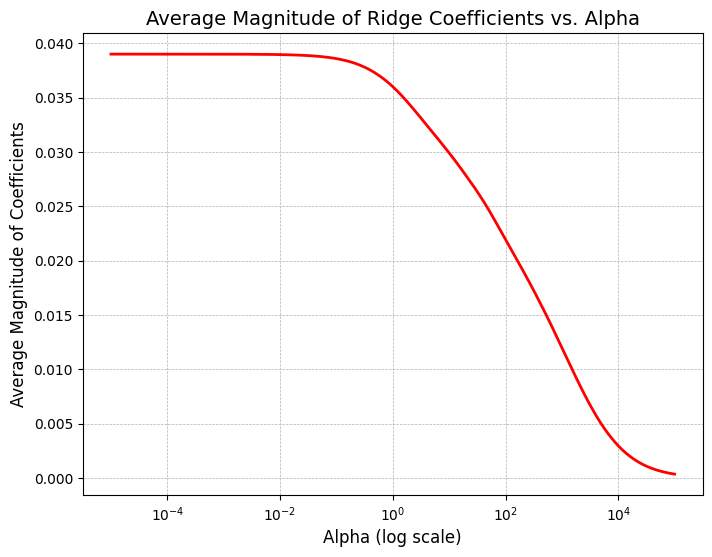

In [12]:
# Here I want to demonstrate the effect of the penalty parameter alpha on the average size of regression coefficients

# List to store the average magnitude of coefficients (betas) for each alpha
avg_coef_magnitudes = []

# Loop over each alpha value
for alpha in alphas:
    # Initialize the Ridge regression model with the current alpha
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    # Fit the model on the standardized features and log-transformed response
    ridge.fit(X_scaled, log_Y)
    
    # Extract the coefficients (exclude the intercept)
    coefs = ridge.coef_.ravel()
    
    # Compute the average magnitude (absolute value) of these coefficients
    avg_magnitude = np.mean(np.abs(coefs))
    avg_coef_magnitudes.append(avg_magnitude)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(alphas, avg_coef_magnitudes, color='red', lw=2)
plt.xscale('log')  # Use a logarithmic scale for alpha values
plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Average Magnitude of Coefficients', fontsize=12)
plt.title('Average Magnitude of Ridge Coefficients vs. Alpha', fontsize=14)
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show(block=False)

In [13]:
# Bootstrap resampling helps us estimate the uncertainty (variability) of our coefficients.
# We repeatedly resample the data and refit the model to obtain a distribution of coefficient estimates.
n_bootstraps = 1000  # Number of bootstrap samples.
# Initialize an array to store coefficients from each bootstrap iteration.
bootstrap_coefs = np.zeros((n_bootstraps, len(X_cols) + 1))  # +1 for the intercept.

# TODO 3: Bootstrap Implementation
# Implement the bootstrap resampling loop
# Hint: Use resample() from sklearn.utils
# Hint: For each iteration out of n_bootstraps:
# 1. Create bootstrap sample
# 2. Fit Ridge model with optimal alpha
# 3. Store coefficients (use bootstrap_coefs np.array variable for this)

#!# BEGIN SOLUTION
# Perform bootstrap resampling.
for i in range(n_bootstraps):
    # Resample the data (with replacement) to create a new bootstrap sample.
    X_scaled_boot, log_Y_boot = resample(X_scaled, log_Y)
    # Fit the Ridge regression on this bootstrap sample using the optimal alpha.
    model_boot = Ridge(alpha=optimal_alpha, fit_intercept=True)
    model_boot.fit(X_scaled_boot, log_Y_boot)
    # Store the intercept and coefficients from the bootstrap model.
    bootstrap_coefs[i, :] = np.concatenate((model_boot.intercept_.ravel(), model_boot.coef_.ravel()))
#!# END SOLUTION

In [14]:

# TODO 4: Confidence Intervals, probabilities and standard deviation errors

#!# BEGIN SOLUTION
# Calculate the standard errors of the coefficients from the bootstrap samples.
bootstrap_std_errors = bootstrap_coefs.std(axis=0)

# Calculate the 95% confidence intervals (using the 2.5th and 97.5th percentiles).
ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)
median   = np.percentile(bootstrap_coefs, 50, axis=0)  # The median value.

# Compute the probability that each coefficient is greater than 0.
# This is the proportion of bootstrap samples for which the coefficient is positive.
prob_positive = np.mean(bootstrap_coefs > 0, axis=0)
#!# END SOLUTION

# Create a summary DataFrame with the bootstrap results.
summary_df = pd.DataFrame({
    "Coefficient": beta_names,
    "Median": median,
    "95% CI Lower": ci_lower,
    "95% CI Upper": ci_upper,
    "Bootstrap Std Error": bootstrap_std_errors,
    "Pr(>0)": prob_positive
})

print("\nSummary Table:")
print(summary_df.to_string(index=False))


Summary Table:
                                                                            Coefficient  Median  95% CI Lower  95% CI Upper  Bootstrap Std Error  Pr(>0)
                                                                            (intercept)  0.8905        0.8436        0.9360               0.0234  1.0000
                                                                      goal.pol.econ.rel  0.0172        0.0040        0.0306               0.0070  0.9930
                                                                  goal.coerce.intim.pub -0.0004       -0.0155        0.0161               0.0086  0.4830
                                                                       goal.out.hum.law -0.0217       -0.0472        0.0051               0.0136  0.0470
                                                                    attack.24hours.plus -0.0139       -0.0352        0.0092               0.0113  0.1120
                                                             unaff

In [15]:
# Function to Plot Bootstrap Distribution
def plot_bootstrap(bootstrap_coefs, beta_names=None, selected_vars=None, point_est='median'):
    """
    Plot bootstrap distributions for selected parameters, computing summary statistics
    directly from the bootstrap simulations.
    
    Parameters:
      bootstrap_coefs : ndarray
          Array of bootstrap simulation results (shape: n_bootstraps x n_parameters).
      beta_names : list of str, optional
          Names of the parameters. If not provided, default names ('Param0', 'Param1', ...) are used.
      selected_vars : list, optional
          List of variables to plot. Can be provided as indices (int) or as names (str).
          If None, the function plots all parameters.
      point_est : str, optional
          Method for computing the point estimate from bootstrap samples. Options are
          'mean' or 'median' (default is 'median').
    
    The function computes:
      - A point estimate (mean or median) for each parameter,
      - 95% confidence intervals (2.5th and 97.5th percentiles),
      - The probability that the coefficient is > 0.
    
    For each selected parameter, it plots:
      - A histogram of the bootstrap coefficients,
      - A dashed vertical line at the point estimate,
      - A solid vertical line at 0,
      - A legend showing the point estimate, confidence intervals, and Pr(β > 0).
    """
    # Determine the total number of parameters.
    n_params = bootstrap_coefs.shape[1]
    # Create default parameter names if none are provided.
    if beta_names is None:
        beta_names = [f"Param{i}" for i in range(n_params)]

    # TODO 5: Plotting Function Implementation
    # In the plot_bootstrap function, implement:
    # 1. Point estimate calculation (mean/median)
    # 2. Confidence interval calculation
    # 3. Probability positive calculation
    
    #!# BEGIN SOLUTION
    # Compute the point estimate based on the user's choice (mean or median).
    if point_est == 'mean':
        est = np.mean(bootstrap_coefs, axis=0)
    elif point_est == 'median':
        est = np.median(bootstrap_coefs, axis=0)
    else:
        raise ValueError("point_est must be either 'mean' or 'median'")
    
    # Calculate the 95% confidence intervals and the probability that coefficients are > 0.
    ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
    ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)
    prob_positive = np.mean(bootstrap_coefs > 0, axis=0)
    #!# END SOLUTION
    
    # Determine which parameters to plot.
    if selected_vars is None:
        indices = range(n_params)
    else:
        # If the user provided indices.
        if all(isinstance(x, int) for x in selected_vars):
            indices = selected_vars
        # If the user provided names.
        elif all(isinstance(x, str) for x in selected_vars):
            indices = []
            for var in selected_vars:
                if var in beta_names:
                    indices.append(beta_names.index(var))
                else:
                    print(f"Warning: {var} not found in beta_names.")
        else:
            raise ValueError("selected_vars must be a list of either ints or strs.")
    
    # Create subplots: one for each selected parameter.
    n_plots = len(indices)
    fig, axes = plt.subplots(n_plots, 1, figsize=(8, 3 * n_plots))
    # Ensure that axes is always a list (even if there's only one plot).
    if n_plots == 1:
        axes = [axes]
    
    # Loop over each selected parameter to create its histogram.
    for ax, idx in zip(axes, indices):
        # Plot histogram of the bootstrap coefficients for parameter idx.
        ax.hist(bootstrap_coefs[:, idx], bins=30, edgecolor='white', alpha=0.7)
        # Draw a dashed line at the point estimate (with CI info in the legend).
        ax.axvline(est[idx], color='black', linestyle='dashed', linewidth=1,
                   label=(f'Optimal = {est[idx]:.2f}[{ci_lower[idx]:.2f}, {ci_upper[idx]:.2f}]\n'
                          f'Pr(β > 0) = {prob_positive[idx]:.2f}'))
        # Draw a solid blue line at zero.
        ax.axvline(0, color='black', linestyle='solid', linewidth=1, label='0 effect')
        ax.set_title(f'Bootstrap Distribution for {beta_names[idx]}')
        ax.legend()
    
    plt.tight_layout()
    plt.show(block=False)

In [16]:
# TODO 6: Significant Coefficients
# Identify significant coefficients using bootstrap probabilities
# Consider "significant" if Pr(>0) <= 0.1 or >= 0.9

#!# BEGIN SOLUTION
# Here, we consider a coefficient "significant" if its bootstrap probability of being positive
# is either very low (<= 0.1) or very high (>= 0.9).
sig_idx = np.where((prob_positive <= 0.1) | (prob_positive >= 0.9))[0]
#!# END SOLUTION
sig_names = [beta_names[i] for i in sig_idx]

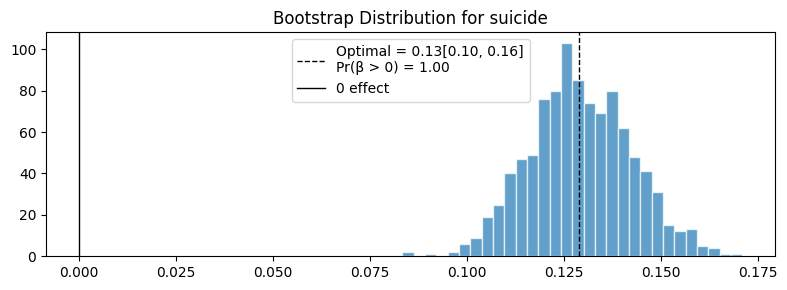

In [17]:
# As an example, plot the bootstrap distribution for the 'suicide' coefficient.
# This visualisation shows the spread of bootstrap estimates and the calculated statistics.
plot_bootstrap(
    selected_vars = ['suicide'],  # Specify the variable to plot by name.
    beta_names = beta_names,
    bootstrap_coefs = bootstrap_coefs
)

#### Part 2): Ridge Regression v. Linear Regression for Prediction

In [18]:
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import statsmodels.api as sm
from scipy.stats import spearmanr

In [19]:
# Prepare dataset -- 
# here I use a slightly bigger subsample as I don't have to plot coefficients etc. 
# and it might make for a more interesting prediction test

# Remove rows that contain any missing values.
YX_nona = YX.dropna()

# For simplicity and speed, take a random subsample of 1000 observations.
YX_nona = YX_nona.sample(n=1000, random_state=42)

# Zero variance columns (constant columns) do not provide useful information in regression.
variances = YX_nona.var(axis=0)  # Calculate variance for each column.
kept_columns = (variances != 0)   # Create a mask that is True for columns with non-zero variance.

# Keep only the columns with non-zero variance.
YX_nona_variable = YX_nona.loc[:, kept_columns]

# Update our feature list to include only those columns that were kept.
X_cols = [col for col in X_cols if kept_columns.get(col, False)]

# Split Data into Features (X) and Response (Y)
X = YX_nona_variable[X_cols]
Y = YX_nona_variable[Y_cols]

# To help with normality, transform the response by taking the log.
# Adding 1 ensures that we do not take the log of 0.
log_Y = np.log(Y + 1)

# Standardisation (z-scoring) centers the data and scales it to unit variance,
# which is important when using regularization (like Ridge regression).
X_scaled = scaler.fit_transform(X)

In [20]:
# We split the (standardised) design matrix, the log-response, the original Y,
# and also preserve the indices (from the sampled dataset) so we can later retrieve the year.
X_train, X_test, log_Y_train, log_Y_test, idx_train, idx_test = train_test_split(
    X_scaled, log_Y, YX_nona_variable.index, test_size=0.3, random_state=42
)

In [21]:
# TODO 7: Constant to training / test set
# Add a constant to the training / test datasets using statsmodels.api (sm) imported above.
# Hint: Use sm.OLS() and don't forget to add a constant to the training

# 1. Linear Regression fit and out-of-sample predictions

# Add a constant (intercept) to both training and test sets.
X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

# TODO 8: OLS Model Fitting
# Fit an Ordinary Least Squares (OLS) model using statsmodels
# Hint: Use sm.OLS() and use the training set where you added a constant.
ols_model = sm.OLS(log_Y_train, X_train_const).fit()

In [22]:
# TODO 9: OLS Prediction Intervals
# Generate predictions and prediction intervals for the test set with constant
# Hint: Use get_prediction() and summary_frame()

#!# BEGIN SOLUTION
# --- Generate predictions on the test set, including prediction intervals ---
# We use get_prediction to obtain predictions and their corresponding intervals.
predictions = ols_model.get_prediction(X_test_const)
pred_summary = predictions.summary_frame(alpha=0.05)  # 95% prediction intervals

# --- Extract predicted log-values and the lower/upper bounds of the prediction intervals ---
lr_pred_log          = pred_summary['mean'].values
lr_pred_int_lower_log = pred_summary['obs_ci_lower'].values
lr_pred_int_upper_log = pred_summary['obs_ci_upper'].values
#!# END SOLUTION

~/.ai-navigator/conda/lib/python3.12/site-packages/statsmodels/regression/_prediction.py:56: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(self.var_pred_mean + self.var_resid)
~/.ai-navigator/conda/lib/python3.12/site-packages/statsmodels/regression/_prediction.py:75: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(self.var_pred_mean)


In [23]:
# 2. Ridge Regression with Bootstrap Prediction Intervals

# TODO 10: Fit Ridge Model and make predictions
# Similar to TODO 2, create and fit a Ridge regression model with the optimal alpha previously found there and fit_intercept=True
# Hint: Use X_train and log_Y_train as your datasets
# Hint: Make predictions using X_test and save them into ridge_pred_log

#!# BEGIN SOLUTION
# Fit the ridge regression model on the training data using the optimal alpha.
ridge_model2 = Ridge(alpha=optimal_alpha, fit_intercept=True)
ridge_model2.fit(X_train, log_Y_train)
ridge_pred_log = ridge_model2.predict(X_test)
#!# END SOLUTION


In [24]:
# Estimate prediction intervals for ridge via bootstrap.
n_bootstraps = 1000
ridge_preds_boot = np.zeros((n_bootstraps, len(X_test)))  # to store predictions for each bootstrap

# TODO 11: Implement the bootstrap loop for ridge regression prediction intervals
# Hint: The implementation is very similar to TODO 3
# Hint: Resample indices, fit ridge model on bootstrap sample, store predictions

#!# BEGIN SOLUTION
for i in range(n_bootstraps):
    # Resample indices from the training set (using integer positions)
    bootstrap_indices = resample(np.arange(len(X_train)), replace=True)
    
    # Use .iloc to index the pandas DataFrame/Series if necessary.
    X_train_boot = X_train.iloc[bootstrap_indices] if hasattr(X_train, 'iloc') else X_train[bootstrap_indices]
    log_Y_train_boot = log_Y_train.iloc[bootstrap_indices] if hasattr(log_Y_train, 'iloc') else log_Y_train[bootstrap_indices]
    
    # Fit a ridge model on the bootstrap sample.
    ridge_boot = Ridge(alpha=optimal_alpha, fit_intercept=True)
    ridge_boot.fit(X_train_boot, log_Y_train_boot)
    
    # Predict on the test set and convert the output to a 1D array.
    ridge_preds_boot[i, :] = ridge_boot.predict(X_test).ravel()
#!# END SOLUTION

# For each test observation, compute the 2.5th and 97.5th percentiles of the bootstrap predictions.
ridge_pred_int_lower_log = np.percentile(ridge_preds_boot, 2.5, axis=0)
ridge_pred_int_upper_log = np.percentile(ridge_preds_boot, 97.5, axis=0)

In [25]:
# 3. Compute Performance Metrics (on the original scale)

# Convert Y_test_orig (which might be a DataFrame/Series) to a flat NumPy array.
log_Y_test_arr = log_Y_test.values.flatten() 

# TODO 12: Calculate Performance Metrics ====
# Compute evaluation metrics for both models
# Hint: Use np.mean() and np.sqrt() for RMSE, spearmanr() for correlation

#!# BEGIN SOLUTION
# For Linear Regression:
lr_bias     = np.mean(lr_pred_log - log_Y_test_arr)
lr_rmse     = np.sqrt(np.mean((lr_pred_log - log_Y_test_arr)**2))
lr_spearman = spearmanr(log_Y_test_arr, lr_pred_log).correlation
lr_coverage = np.mean((log_Y_test_arr >= lr_pred_int_lower_log) & (log_Y_test_arr <= lr_pred_int_upper_log))

# For Ridge Regression:
ridge_bias     = np.mean(ridge_pred_log - log_Y_test_arr)
ridge_rmse     = np.sqrt(np.mean((ridge_pred_log - log_Y_test_arr)**2))
ridge_spearman = spearmanr(log_Y_test_arr, ridge_pred_log).correlation
ridge_coverage = np.mean((log_Y_test_arr >= ridge_pred_int_lower_log) & (log_Y_test_arr <= ridge_pred_int_upper_log))
#!# END SOLUTION

# Create legend labels that include the metrics.
lr_label = (f"Linear Regression\nBias: {lr_bias:.2f}, RMSE: {lr_rmse:.2f}\n"
            f"Spearman: {lr_spearman:.2f}, Coverage: {lr_coverage*100:.1f}%")
ridge_label = (f"Ridge Regression\nBias: {ridge_bias:.2f}, RMSE: {ridge_rmse:.2f}\n"
               f"Spearman: {ridge_spearman:.2f}, Coverage: {ridge_coverage*100:.1f}%")

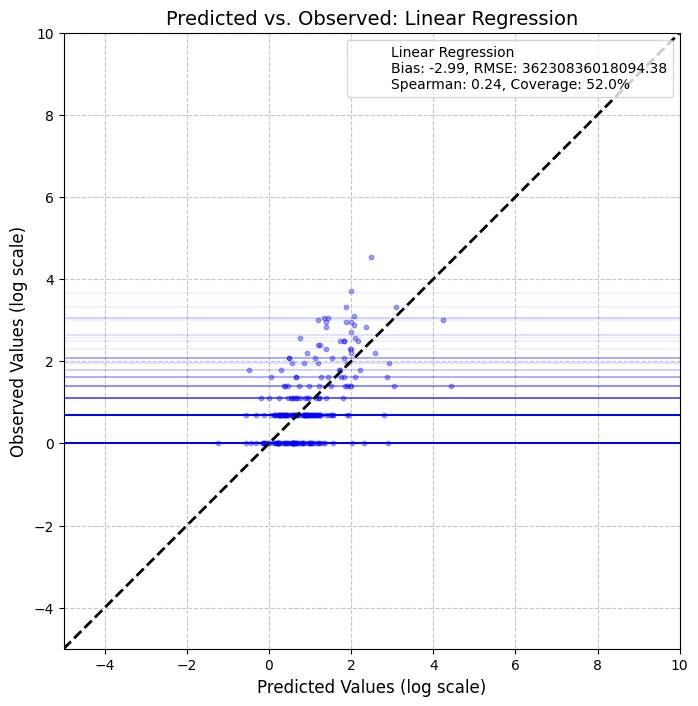

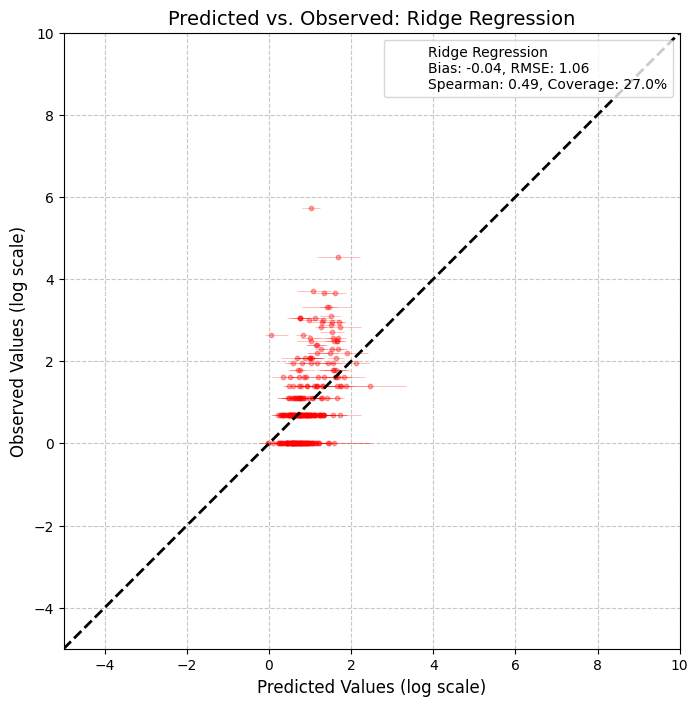

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


lr_pred_log           = np.array(lr_pred_log).flatten()
lr_pred_int_lower_log = np.array(lr_pred_int_lower_log).flatten()
lr_pred_int_upper_log = np.array(lr_pred_int_upper_log).flatten()
ridge_pred_log           = np.array(ridge_pred_log).flatten()
ridge_pred_int_lower_log = np.array(ridge_pred_int_lower_log).flatten()
ridge_pred_int_upper_log = np.array(ridge_pred_int_upper_log).flatten()
log_Y_test_arr       = np.array(log_Y_test_arr).flatten()


# Determine overall min and max values for consistency
min_val = -5 
max_val = 10

# ----------------------------
# Plot for Linear Regression
# ----------------------------

plt.figure(figsize=(8, 8))

# Scatter plot of predicted vs. observed (log scale)
plt.scatter(lr_pred_log, log_Y_test_arr, color='blue', s=10, alpha=0.35)

# Plot horizontal error bars for the 95% prediction intervals.
# Compute the error lengths on the left and right.
lr_err_left  = lr_pred_log - lr_pred_int_lower_log
lr_err_right = lr_pred_int_upper_log - lr_pred_log
plt.errorbar(lr_pred_log, log_Y_test_arr,
             xerr=[lr_err_left, lr_err_right],
             fmt='none', ecolor='blue', lw=0.25, alpha=0.35)

# Plot a 45-degree reference line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)

# Set consistent x and y limits and enforce an equal aspect ratio
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')

# Label axes and title
plt.xlabel("Predicted Values (log scale)", fontsize=12)
plt.ylabel("Observed Values (log scale)", fontsize=12)
plt.title("Predicted vs. Observed: Linear Regression", fontsize=14)

# Create a custom legend entry using a transparent Patch that displays the performance metrics.
lr_legend_handle = Patch(color='none', label=lr_label)
plt.legend(handles=[lr_legend_handle], loc='upper right', frameon=True)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show(block=False)

# ----------------------------
# Plot for Ridge Regression
# ----------------------------

plt.figure(figsize=(8, 8))

# Scatter plot of predicted vs. observed (log scale)
plt.scatter(ridge_pred_log, log_Y_test_arr, color='red', s=10, alpha=0.35)

# Plot horizontal error bars for the 95% prediction intervals.
ridge_err_left  = ridge_pred_log - ridge_pred_int_lower_log
ridge_err_right = ridge_pred_int_upper_log - ridge_pred_log
plt.errorbar(ridge_pred_log, log_Y_test_arr,
             xerr=[ridge_err_left, ridge_err_right],
             fmt='none', ecolor='red', lw=0.5, alpha=0.35)

# Plot a 45-degree reference line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)

# Set consistent x and y limits and enforce an equal aspect ratio
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')

# Label axes and title
plt.xlabel("Predicted Values (log scale)", fontsize=12)
plt.ylabel("Observed Values (log scale)", fontsize=12)
plt.title("Predicted vs. Observed: Ridge Regression", fontsize=14)

# Create a custom legend entry for the ridge performance metrics.
ridge_legend_handle = Patch(color='none', label=ridge_label)
plt.legend(handles=[ridge_legend_handle], loc='upper right', frameon=True)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show(block=False)


Questions: 
1) Why are the predictions from the Linear Regression model so poorly behaved? how can we tell that something fundamental has gone away?

- The prediction with Linear Regression Model poorly behaved due to the multicollinearity. Multicolinearity implies that predicting variables correlate to each other too much that it becomes difficult to draw the difference. The bias of -2.99 and extremely high RMSE also indicate that the model's prediction is unreliable.

2) What can we say about the point estimates of the ridge regression, when comparing to the linear regression? what feature of ridge regression is clearly visible? You can name more than one.
- Based on the optimal alpha of ridge regularlization Regularaization, Ridge regression employs L2 penalty to the loss function, which shrinks the coefficient toward zero (not exactly to zero). Visually, the horizontal error bars on the plot decreased significantly, fitting closely to the line of best fit. Furthermore, while coverage of the model decreased, Ridge regression improved significantly in reducing bias and RMSE to statistically reliable level. 

3) Which model is best performing and why? describe the meaning of each performance metric.
- Ridge regression performed better as previously explained. Although coverage decreased, bias and RMSE significantly improved from the baseline model, mitigating the overfitting issues. 

# SUMMATIVE ASSESSMENT

Now pick a dataset of your choice. Please ensure your dataset is a csv file under 100MB named sem4_portfolio_1_data_custom.csv

You should choose a dataset for which you have no prior knowledge of the underlying data generating process (i.e. if you're an expert in election, do not pick an elections dataset -- aim to learn something totally new). Ensure the dataset is moderately sized, but has a very large number of features, such that multicollinearity is likely present and regularisation is necessary.  

Using BOTH model regularisation and model selection (Hint: Lasso regression), show how penalised regression models can be used to learn about the distribution of the effect of useful features , and generate accurate predictions for the target of interest. 

In [27]:
# Do NOT modify the contents of this cell. Start your customization in the next one!
custom_data_path = "sem4_portfolio_1_data_custom.csv"
c_df = pd.read_csv(custom_data_path)

In [28]:
# Feel free to add any code or markdown cells between here and the final code cell, and fill them with your custom analysis!

# WHO - Life Expectancy Dataset
https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who

### 0) Import libraries

In [29]:
# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.patches import Patch

In [30]:
# Set display options
np.set_printoptions(suppress=True, precision=6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

### 1) Explore Data

In [31]:
# Display first few rows
c_df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0000,263.0000,62,0.0100,71.2796,65.0000,1154,19.1000,83,6.0000,8.1600,65.0000,0.1000,584.2592,33736494.0000,17.2000,17.3000,0.4790,10.1000
1,Afghanistan,2014,Developing,59.9000,271.0000,64,0.0100,73.5236,62.0000,492,18.6000,86,58.0000,8.1800,62.0000,0.1000,612.6965,327582.0000,17.5000,17.5000,0.4760,10.0000
2,Afghanistan,2013,Developing,59.9000,268.0000,66,0.0100,73.2192,64.0000,430,18.1000,89,62.0000,8.1300,64.0000,0.1000,631.7450,31731688.0000,17.7000,17.7000,0.4700,9.9000
3,Afghanistan,2012,Developing,59.5000,272.0000,69,0.0100,78.1842,67.0000,2787,17.6000,93,67.0000,8.5200,67.0000,0.1000,669.9590,3696958.0000,17.9000,18.0000,0.4630,9.8000
4,Afghanistan,2011,Developing,59.2000,275.0000,71,0.0100,7.0971,68.0000,3013,17.2000,97,68.0000,7.8700,68.0000,0.1000,63.5372,2978599.0000,18.2000,18.2000,0.4540,9.5000


In [32]:
# Check for missing values
print("\nMissing values in each column:")
print(c_df.isna().sum())


Missing values in each column:
Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64


In [33]:
# Print all column names to confirm
print("\nActual column names in the dataset:")
print(list(c_df.columns))


Actual column names in the dataset:
['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', 'BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


### 2) Data Pre-processing

In [34]:
# Clean column names by removing leading/trailing spaces
c_df.columns = c_df.columns.str.strip()

In [35]:
# 1. Convert the 'Year' column to categorical objects to work with years as categories.
c_df['Year'] = c_df['Year'].astype('category')

# 2. Convert the 'year' column to a categorical variable. 
# This is useful if you want to treat the year as a factor rather than a continuous variable.
c_df['Year'] = c_df['Year'].astype('category')

In [36]:
# Convert several categorical columns into dummy/indicator variables (one-hot encoding).
cat_cols = ['Country', 'Year', 'Status']
c_df_dummies = pd.get_dummies(c_df, columns=cat_cols, drop_first=False)

In [37]:
# These lists define which columns to use as features (X) and which as the response (Y).

# Define all numeric predictors (excluding the response and the original categorical columns already encoded).
numeric_cols = [
    'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 
    'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 
    'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 
    'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling'
]

# Dummy columns: these are created from the categorical variables in c_df_dummies.
dummy_cols = [
    col for col in c_df_dummies.columns 
    if col.startswith('Country_') 
       or col.startswith('Year_') 
       or col.startswith('Status_')
]

# Combine all the features into one master list.
# NOTICE: I'm leaving all the coefficients in, as the dummy trap gets solved by the penalized regression
X_cols = numeric_cols + dummy_cols

# The outcome (response) variable is 'Life expectancy'.
Y_cols = ['Life expectancy']

# Create a combined list of columns that includes the response and the features.
YX_cols = Y_cols + X_cols

# Subset the dataframe to include only these columns.
YX = c_df_dummies[YX_cols]

# Remove rows that contain any missing values.
YX_nona = YX.dropna()

# For simplicity and speed, take a random subsample of 1000 observations.
YX_nona = YX_nona.sample(n=1000, random_state=42)

In [38]:
Y_cols

['Life expectancy']

In [39]:
# Zero variance columns (constant columns) do not provide useful information in regression.
variances = YX_nona.var(axis=0)  # Calculate variance for each column.
kept_columns = (variances != 0)   # Create a mask that is True for columns with non-zero variance.

# Keep only the columns with non-zero variance.
YX_nona_variable = YX_nona.loc[:, kept_columns]

# Update our feature list to incX = YX_nona_variable[X_cols]ude only those columns that were kept.
X_cols = [col for col in X_cols if kept_columns.get(col, False)]

### 3) Check for Multicollinearity with VIF

In [40]:
# Filter X_cols to include only numeric predictors for VIF calculation
vif_cols = [col for col in X_cols if col in numeric_cols]

# Subset the DataFrame to include only numeric predictors for VIF
c_df_vif = YX_nona_variable[vif_cols]

# Standardize features for VIF
scaler = StandardScaler()
X_scaled_vif = scaler.fit_transform(c_df_vif)
X_vif = pd.DataFrame(X_scaled_vif, columns=vif_cols)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\nVariance Inflation Factors (VIF) for Numeric Predictors:")
print(vif_data)


Variance Inflation Factors (VIF) for Numeric Predictors:
                           Variable      VIF
0                   Adult Mortality   1.7222
1                     infant deaths 236.2987
2                           Alcohol   1.9462
3            percentage expenditure   8.9513
4                       Hepatitis B   1.7837
5                           Measles   1.7224
6                               BMI   1.8612
7                 under-five deaths 224.0014
8                             Polio   1.6328
9                 Total expenditure   1.1158
10                       Diphtheria   2.1045
11                         HIV/AIDS   1.4331
12                              GDP   9.6236
13                       Population   1.9686
14             thinness  1-19 years   8.6976
15               thinness 5-9 years   8.7754
16  Income composition of resources   3.8606
17                        Schooling   3.9424


In [41]:
# Identify predictors with high VIF (e.g., VIF > 10)
high_vif_predictors = vif_data[vif_data["VIF"] > 10]["Variable"].tolist()
print("\nPredictors with High Multicollinearity (VIF > 10):")
print(high_vif_predictors)


Predictors with High Multicollinearity (VIF > 10):
['infant deaths', 'under-five deaths']


In [42]:
# Prepare dataset --

# Remove rows that contain any missing values.
YX_nona = YX.dropna()

# Check the number of rows after dropping NA
print(f"Number of rows in YX_nona after dropna: {len(YX_nona)}")

# For simplicity and speed, take a random subsample of 2000 observations (or fewer if not enough rows).
desired_sample_size = 2000
actual_sample_size = min(desired_sample_size, len(YX_nona))
print(f"Sampling {actual_sample_size} rows (desired: {desired_sample_size})")
YX_nona = YX_nona.sample(n=actual_sample_size, random_state=42)

# Zero variance columns (constant columns) do not provide useful information in regression.
variances = YX_nona.var(axis=0)  # Calculate variance for each column.
kept_columns = (variances != 0)   # Create a mask that is True for columns with non-zero variance.

# Keep only the columns with non-zero variance.
YX_nona_variable = YX_nona.loc[:, kept_columns]

# Update our feature list to include only those columns that were kept.
X_cols = [col for col in X_cols if kept_columns.get(col, False)]

# Split Data into Features (X) and Response (Y)
X = YX_nona_variable[X_cols]
Y = YX_nona_variable[Y_cols]

# To help with normality, transform the response by taking the log.
# Adding 1 ensures that we do not take the log of 0.
log_Y = np.log(Y + 1)

# Standardisation (z-scoring) centers the data and scales it to unit variance,
# which is important when using regularization (like Ridge regression).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the standardized data into training and test sets
X_scaled_train, X_scaled_test, log_Y_train, log_Y_test = train_test_split(
    X_scaled, log_Y, test_size=0.2, random_state=42
)

Number of rows in YX_nona after dropna: 1649
Sampling 1649 rows (desired: 2000)


- High VIF values > 10 for variables like infant deaths and under-five deaths indicate multicollinearity.
- 'infant deaths', 'Under-five deaths'

### 4) Split and Standardize Data

In [43]:
# Split Data into Features (X) and Response (Y)
X = YX_nona_variable[X_cols]
Y = YX_nona_variable[Y_cols]

# To help with normality, transform the response by taking the log.
# Adding 1 ensures that we do not take the log of 0.
log_Y = np.log(Y + 1)

In [44]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [45]:
from sklearn.model_selection import train_test_split

# Split the standardized data into training and test sets
X_scaled_train, X_scaled_test, log_Y_train, log_Y_test = train_test_split(
    X_scaled, log_Y, test_size=0.2, random_state=42
)

# Fit Linear Regression model
lr_model = LinearRegression(fit_intercept=True)
lr_model.fit(X_scaled_train, log_Y_train)

LinearRegression()

## Regularization with Ridge Regression method

### 6) Optimal Alpha (Ridge)

In [46]:
# Standardize the features (X) since Ridge is sensitive to scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use cross-validation to choose the optimal regularization parameter (alpha).
# We test a wide range of candidate alpha values on a logarithmic scale.
alphas = np.logspace(-5, 5, 1000)

# RidgeCV Setup
# Create a RidgeCV model with specified alphas, fit_intercept=True, and negative MSE scoring
ridge_cv = RidgeCV(alphas=alphas, fit_intercept=True, scoring='neg_mean_squared_error')
ridge_cv.fit(X_scaled_train, log_Y_train)  # Use training data

optimal_alpha = ridge_cv.alpha_  # Optimal alpha determined by cross-validation.
print(f"Optimal alpha found via cross-validation: {optimal_alpha:.4f}")

Optimal alpha found via cross-validation: 0.1394


- There are some multicollinearity but no so severe that a large penalty is needed.

In [47]:
# Fit Ridge Model
# Create and fit a Ridge regression model with the optimal alpha previously found and fit_intercept=True
ridge_model = Ridge(alpha=optimal_alpha, fit_intercept=True)
ridge_model.fit(X_scaled_train, log_Y_train)  # Use training data

# Combine the intercept and coefficients into one array for later reference.
beta_hat = np.concatenate((ridge_model.intercept_.ravel(), ridge_model.coef_.ravel()))

# Create a list of names for the coefficients, starting with the intercept.
beta_names = ['(intercept)'] + X_cols

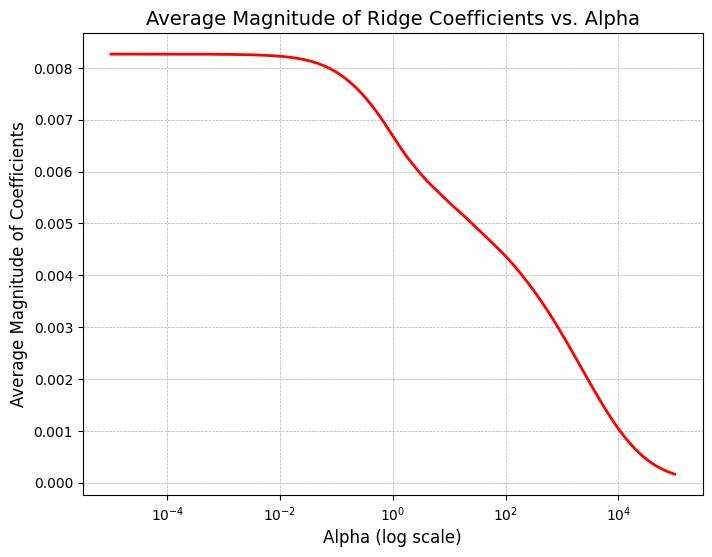

In [48]:
# Calculate average coefficient magnitude for each alpha
avg_coef_magnitudes = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    ridge.fit(X_scaled_train, log_Y_train)  # Use training data
    avg_magnitude = np.mean(np.abs(ridge.coef_))
    avg_coef_magnitudes.append(avg_magnitude)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(alphas, avg_coef_magnitudes, color='red', lw=2)
plt.xscale('log')
plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Average Magnitude of Coefficients', fontsize=12)
plt.title('Average Magnitude of Ridge Coefficients vs. Alpha', fontsize=14)
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

### 7) Bootstrap Distribution (Ridge)

#### Bootstrap Resampling for Coefficient Uncertainty

In [49]:
# Bootstrap resampling helps us estimate the uncertainty (variability) of our coefficients.
# We repeatedly resample the data and refit the model to obtain a distribution of coefficient estimates.
n_bootstraps = 1000  # Number of bootstrap samples.
# Initialize an array to store coefficients from each bootstrap iteration.
bootstrap_coefs = np.zeros((n_bootstraps, len(X_cols) + 1))  # +1 for the intercept.

from sklearn.utils import resample

for i in range(n_bootstraps):
    X_resampled, y_resampled = resample(X_scaled_train, log_Y_train, replace=True, random_state=i)

    ridge = Ridge(alpha=optimal_alpha, fit_intercept=True)
    ridge.fit(X_resampled, y_resampled)

    bootstrap_coefs[i, 0] = ridge.intercept_
    bootstrap_coefs[i, 1:] = ridge.coef_

/var/folders/rf/c4wm9pq50j3bjhbyfct63d2h0000gn/T/ipykernel_18478/3528083747.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bootstrap_coefs[i, 0] = ridge.intercept_
/var/folders/rf/c4wm9pq50j3bjhbyfct63d2h0000gn/T/ipykernel_18478/3528083747.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bootstrap_coefs[i, 0] = ridge.intercept_
/var/folders/rf/c4wm9pq50j3bjhbyfct63d2h0000gn/T/ipykernel_18478/3528083747.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  

#### Calculate Confidence Intervals, Probabilities, and SE

In [50]:
# Calculate the standard errors of the coefficients from the bootstrap samples.
bootstrap_std_errors = np.std(bootstrap_coefs, axis=0, ddof=1)

# Calculate the 95% confidence intervals (using the 2.5th and 97.5th percentiles), and the median value.
# Hint: Use np.percentile for CIs (2.5th and 97.5th percentiles)
ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)
median = np.median(bootstrap_coefs, axis=0)

# Compute the probability that each coefficient is greater than 0.
# This is the proportion of bootstrap samples for which the coefficient is positive.
# Hint: prob_positive is the mean of (bootstrap_coefs > 0)
prob_positive = np.mean(bootstrap_coefs > 0, axis=0)

# Create a summary DataFrame with the bootstrap results.
summary_df = pd.DataFrame({
    "Coefficient": beta_names,
    "Median": median,
    "95% CI Lower": ci_lower,
    "95% CI Upper": ci_upper,
    "Bootstrap Std Error": bootstrap_std_errors,
    "Pr(>0)": prob_positive
})

print("\nSummary Table:")
print(summary_df.to_string(index=False))


Summary Table:
                     Coefficient  Median  95% CI Lower  95% CI Upper  Bootstrap Std Error  Pr(>0)
                     (intercept)  4.2439        4.2425        4.2454               0.0007  1.0000
                 Adult Mortality -0.0019       -0.0054        0.0017               0.0018  0.1590
                   infant deaths  0.0600        0.0233        0.1214               0.0247  1.0000
                         Alcohol -0.0025       -0.0071        0.0018               0.0022  0.1170
          percentage expenditure -0.0015       -0.0072        0.0037               0.0028  0.2930
                     Hepatitis B  0.0012       -0.0007        0.0033               0.0010  0.8770
                         Measles -0.0008       -0.0044        0.0021               0.0017  0.3250
                             BMI -0.0005       -0.0024        0.0014               0.0010  0.3150
               under-five deaths -0.0634       -0.1403       -0.0278               0.0274  0.0000
    


Plotting bootstrap distributions for predictors with high multicollinearity (VIF > 10):


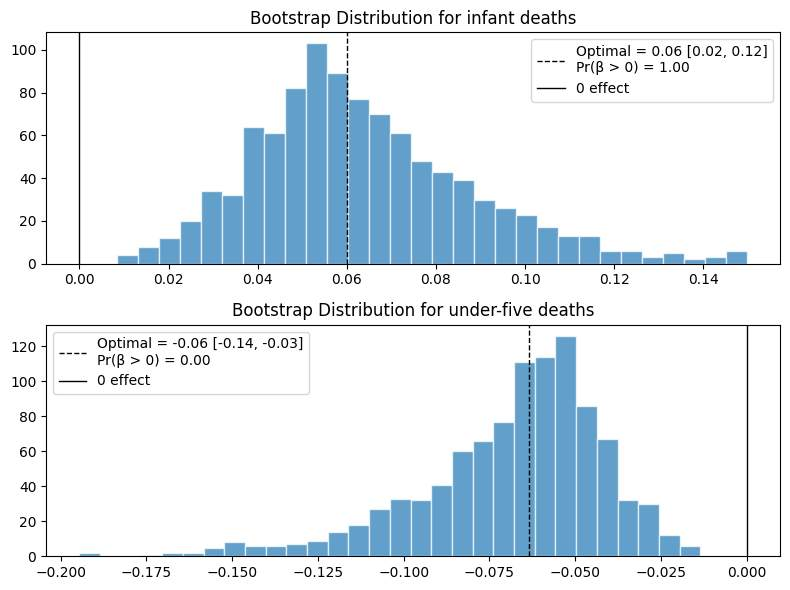

In [51]:
# Function to Plot Bootstrap Distribution
def plot_bootstrap(bootstrap_coefs, beta_names=None, selected_vars=None, point_est='median'):

    # Determine the total number of parameters.
    n_params = bootstrap_coefs.shape[1]
    # Create default parameter names if none are provided.
    if beta_names is None:
        beta_names = [f"Param{i}" for i in range(n_params)]

    # Compute the point estimate based on the user's choice (mean/median).
    if point_est == 'mean':
        est = np.mean(bootstrap_coefs, axis=0)
    elif point_est == 'median':
        est = np.median(bootstrap_coefs, axis=0)
    else:
        raise ValueError("point_est must be either 'mean' or 'median'")
    
    # Calculate the 95% confidence intervals and the probability that coefficients are > 0.
    ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
    ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)
    prob_positive = np.mean(bootstrap_coefs > 0, axis=0)
    
    # Determine which parameters to plot.
    if selected_vars is None:
        indices = range(n_params)
    else:
        # If the user provided indices.
        if all(isinstance(x, int) for x in selected_vars):
            indices = selected_vars
        # If the user provided names.
        elif all(isinstance(x, str) for x in selected_vars):
            indices = []
            for var in selected_vars:
                if var in beta_names:
                    indices.append(beta_names.index(var))
                else:
                    print(f"Warning: {var} not found in beta_names.")
        else:
            raise ValueError("selected_vars must be a list of either ints or strs.")
    
    # Create subplots: one for each selected parameter.
    n_plots = len(indices)
    fig, axes = plt.subplots(n_plots, 1, figsize=(8, 3 * n_plots))
    # Ensure that axes is always a list (even if there's only one plot).
    if n_plots == 1:
        axes = [axes]
    
    # Loop over each selected parameter to create its histogram.
    for ax, idx in zip(axes, indices):
        # Plot histogram of the bootstrap coefficients for parameter idx.
        ax.hist(bootstrap_coefs[:, idx], bins=30, edgecolor='white', alpha=0.7)
        # Draw a dashed line at the point estimate (with CI info in the legend).
        ax.axvline(est[idx], color='black', linestyle='dashed', linewidth=1,
                   label=(f'Optimal = {est[idx]:.2f} [{ci_lower[idx]:.2f}, {ci_upper[idx]:.2f}]\n'
                          f'Pr(β > 0) = {prob_positive[idx]:.2f}'))
        # Draw a solid black line at zero (fixed syntax from original).
        ax.axvline(0, color='black', linestyle='solid', linewidth=1, label='0 effect')
        ax.set_title(f'Bootstrap Distribution for {beta_names[idx]}')
        ax.legend()
    
    plt.tight_layout()
    plt.show(block=False)

# Significant Coefficients
# Identify significant coefficients using bootstrap probabilities
# Consider "significant" if Pr(>0) <= 0.1 or >= 0.9
sig_idx = np.where((prob_positive <= 0.1) | (prob_positive >= 0.9))[0]
sig_names = [beta_names[i] for i in sig_idx]

# Plot the bootstrap distribution for predictors with high multicollinearity
# Use high_vif_predictors from the VIF analysis
print("\nPlotting bootstrap distributions for predictors with high multicollinearity (VIF > 10):")
plot_bootstrap(
    selected_vars=high_vif_predictors,  # Plot predictors with high VIF
    beta_names=beta_names,
    bootstrap_coefs=bootstrap_coefs
)

- The bootstrap distribution for 'infant deaths' indicates highly positive effect on log-transformed 'Life expectancy' with no overlap with zero. Hence, it suggest robustness in its estimate despite potential multicollinearity with 'under-five deaths'.

- The bootstrap distribution for 'under-five deaths' shows negative coefficient, implying significant negative effect on log-transformed 'Life expectancy', likely influenced by multicollinearity with 'infant deaths'.

### 8) Ridge Regression vs. Linear Regression for Prediction

Prepare Dataset and Split into Training/Test Sets

In [52]:
# Remove rows that contain any missing values.
YX_nona = YX.dropna()

# For simplicity and speed, take a random subsample of 1000 observations.
YX_nona = YX_nona.sample(n=1000, random_state=42)

# Zero variance columns (constant columns) do not provide useful information in regression.
variances = YX_nona.var(axis=0)  # Calculate variance for each column.
kept_columns = (variances != 0)   # Create a mask that is True for columns with non-zero variance.

# Keep only the columns with non-zero variance.
YX_nona_variable = YX_nona.loc[:, kept_columns]

# Update our feature list to include only those columns that were kept.
X_cols = [col for col in X_cols if kept_columns.get(col, False)]

# Split Data into Features (X) and Response (Y)
X = YX_nona_variable[X_cols]
Y = YX_nona_variable[Y_cols]

# To help with normality, transform the response by taking the log.
# Adding 1 ensures that we do not take the log of 0.
log_Y = np.log(Y + 1)

# Standardisation (z-scoring) centers the data and scales it to unit variance,
# which is important when using regularization (like Ridge regression).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# We split the (standardised) design matrix, the log-response, the original Y,
# and also preserve the indices (from the sampled dataset) so we can later retrieve the year.
X_train, X_test, log_Y_train, log_Y_test, idx_train, idx_test = train_test_split(
    X_scaled, log_Y, YX_nona_variable.index, test_size=0.3, random_state=42
)

Fit OLS Model and Generate Prediction Intervals

In [53]:
# Add a constant (intercept) to both training and test sets.
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

# TODO 8: OLS Model Fitting
# Fit an Ordinary Least Squares (OLS) model using statsmodels
# Hint: Use sm.OLS() and use the training set where you added a constant.
ols_model = sm.OLS(log_Y_train, X_train_const).fit()

# TODO 9: OLS Prediction Intervals
# Generate predictions and prediction intervals for the test set with constant
# Hint: Use get_prediction() and summary_frame()
predictions = ols_model.get_prediction(X_test_const)
pred_summary = predictions.summary_frame(alpha=0.05)

# Hint: Extract predicted log-values and the lower/upper bounds of the prediction intervals from pred_summary
lr_pred_log = pred_summary["mean"]
lr_pred_int_lower_log = pred_summary["obs_ci_lower"]
lr_pred_int_upper_log = pred_summary["obs_ci_upper"]

Fit Ridge Model and Generate Bootstrap Prediction Intervals

In [54]:
# Fit the ridge regression model on the training data using the optimal alpha.
ridge_model2 = Ridge(alpha=optimal_alpha, fit_intercept=True)
ridge_model2.fit(X_train, log_Y_train)
ridge_pred_log = ridge_model2.predict(X_test)

# Estimate prediction intervals for ridge via bootstrap.
n_bootstraps = 1000
ridge_preds_boot = np.zeros((n_bootstraps, len(X_test)))  # to store predictions for each bootstrap

for i in range(n_bootstraps):
    X_resampled, y_resampled = resample(X_train, log_Y_train, replace=True, random_state=i)

    ridge_boot = Ridge(alpha=optimal_alpha, fit_intercept=True)
    ridge_boot.fit(X_resampled, y_resampled)

    ridge_preds_boot[i, :] = ridge_boot.predict(X_test).ravel()

# For each test observation, compute the 2.5th and 97.5th percentiles of the bootstrap predictions.
ridge_pred_int_lower_log = np.percentile(ridge_preds_boot, 2.5, axis=0)
ridge_pred_int_upper_log = np.percentile(ridge_preds_boot, 97.5, axis=0)

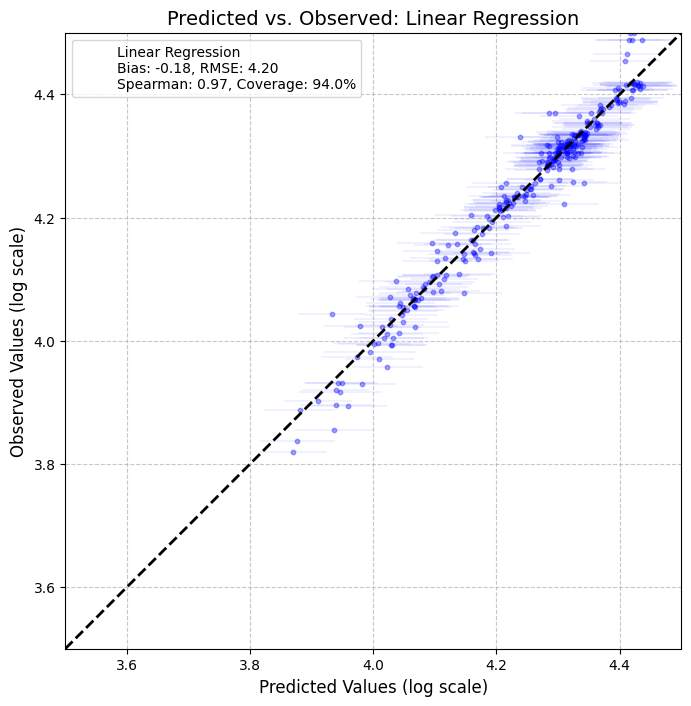

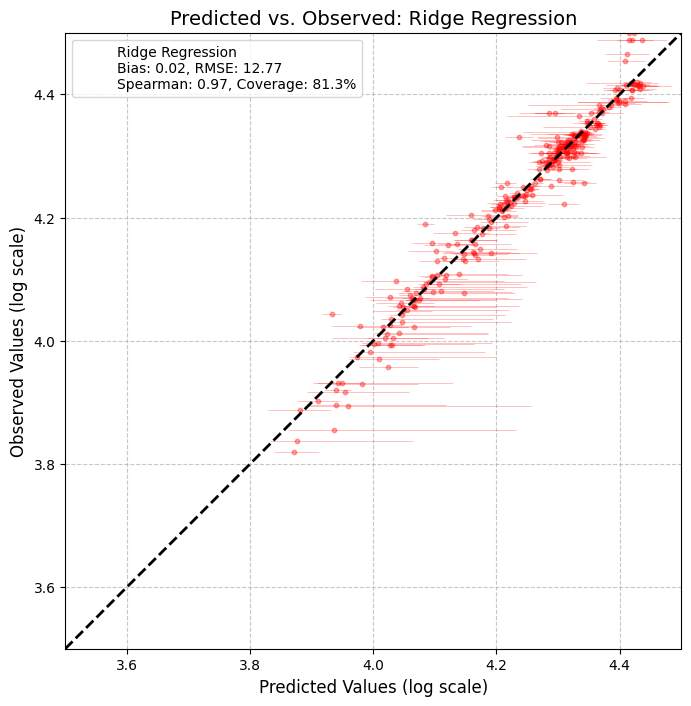

In [55]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 3. Compute Performance Metrics (on the original scale)

# Convert Y_test_orig (which might be a DataFrame/Series) to a flat NumPy array.
log_Y_test_arr = log_Y_test.values.flatten()
Y_test_orig = np.exp(log_Y_test_arr)

# TODO 12: Calculate Performance Metrics
# Compute evaluation metrics for both models
# Hint: Use np.mean() and np.sqrt() for RMSE, spearmanr() for correlation

# For Linear Regression:
lr_pred_orig = np.exp(lr_pred_log)
lr_bias = np.mean(lr_pred_orig - Y_test_orig)
lr_rmse = np.sqrt(np.mean((lr_pred_orig - Y_test_orig) ** 2))
lr_spearman = spearmanr(lr_pred_orig, Y_test_orig).correlation
lr_coverage = np.mean((Y_test_orig >= np.exp(lr_pred_int_lower_log)) & (Y_test_orig <= np.exp(lr_pred_int_upper_log)))

# For Ridge Regression:
ridge_pred_orig = np.exp(ridge_pred_log)
ridge_bias = np.mean(ridge_pred_orig - Y_test_orig)
ridge_rmse = np.sqrt(np.mean((ridge_pred_orig - Y_test_orig) ** 2))
ridge_spearman = spearmanr(ridge_pred_orig, Y_test_orig).correlation
ridge_coverage = np.mean((Y_test_orig >= np.exp(ridge_pred_int_lower_log)) & (Y_test_orig <= np.exp(ridge_pred_int_upper_log)))

# Create legend labels that include the metrics.
lr_label = (f"Linear Regression\nBias: {lr_bias:.2f}, RMSE: {lr_rmse:.2f}\n"
            f"Spearman: {lr_spearman:.2f}, Coverage: {lr_coverage*100:.1f}%")
ridge_label = (f"Ridge Regression\nBias: {ridge_bias:.2f}, RMSE: {ridge_rmse:.2f}\n"
               f"Spearman: {ridge_spearman:.2f}, Coverage: {ridge_coverage*100:.1f}%")

# Ensure all arrays are flattened for plotting
lr_pred_log = np.array(lr_pred_log).flatten()
lr_pred_int_lower_log = np.array(lr_pred_int_lower_log).flatten()
lr_pred_int_upper_log = np.array(lr_pred_int_upper_log).flatten()
ridge_pred_log = np.array(ridge_pred_log).flatten()
ridge_pred_int_lower_log = np.array(ridge_pred_int_lower_log).flatten()
ridge_pred_int_upper_log = np.array(ridge_pred_int_upper_log).flatten()
log_Y_test_arr = np.array(log_Y_test_arr).flatten()

# Determine overall min and max values for consistency
# Adjusted based on typical range of log(Life expectancy + 1)
min_val = 3.5  # Approximate min of log(30 + 1)
max_val = 4.5  # Approximate max of log(90 + 1)

# ----------------------------
# Plot for Linear Regression
# ----------------------------

plt.figure(figsize=(8, 8))

# Scatter plot of predicted vs. observed (log scale)
plt.scatter(lr_pred_log, log_Y_test_arr, color='blue', s=10, alpha=0.35)

# Plot horizontal error bars for the 95% prediction intervals.
# Compute the error lengths on the left and right.
lr_err_left = lr_pred_log - lr_pred_int_lower_log
lr_err_right = lr_pred_int_upper_log - lr_pred_log
plt.errorbar(lr_pred_log, log_Y_test_arr,
             xerr=[lr_err_left, lr_err_right],
             fmt='none', ecolor='blue', lw=0.25, alpha=0.35)

# Plot a 45-degree reference line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)

# Set consistent x and y limits and enforce an equal aspect ratio
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')

# Label axes and title
plt.xlabel("Predicted Values (log scale)", fontsize=12)
plt.ylabel("Observed Values (log scale)", fontsize=12)
plt.title("Predicted vs. Observed: Linear Regression", fontsize=14)

# Create a custom legend entry using a transparent Patch that displays the performance metrics.
lr_legend_handle = Patch(color='none', label=lr_label)
plt.legend(handles=[lr_legend_handle], loc='upper left', frameon=True)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show(block=False)

# ----------------------------
# Plot for Ridge Regression
# ----------------------------

plt.figure(figsize=(8, 8))

# Scatter plot of predicted vs. observed (log scale)
plt.scatter(ridge_pred_log, log_Y_test_arr, color='red', s=10, alpha=0.35)

# Plot horizontal error bars for the 95% prediction intervals.
ridge_err_left = ridge_pred_log - ridge_pred_int_lower_log
ridge_err_right = ridge_pred_int_upper_log - ridge_pred_log
plt.errorbar(ridge_pred_log, log_Y_test_arr,
             xerr=[ridge_err_left, ridge_err_right],
             fmt='none', ecolor='red', lw=0.5, alpha=0.35)

# Plot a 45-degree reference line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)

# Set consistent x and y limits and enforce an equal aspect ratio
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')

# Label axes and title
plt.xlabel("Predicted Values (log scale)", fontsize=12)
plt.ylabel("Observed Values (log scale)", fontsize=12)
plt.title("Predicted vs. Observed: Ridge Regression", fontsize=14)

# Create a custom legend entry for the ridge performance metrics.
ridge_legend_handle = Patch(color='none', label=ridge_label)
plt.legend(handles=[ridge_legend_handle], loc='upper left', frameon=True)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show(block=False)

## Regularization with Lasso regression method

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import train_test_split

#### Train-Test Split

In [57]:
# Ensure the train-test split uses test_size=0.2 (200 test observations)

X_scaled_train, X_scaled_test, log_Y_train, log_Y_test = train_test_split(
    X_scaled, log_Y, test_size=0.2, random_state=42
)

# Verify the shapes
print(f"Shape of X_scaled_test: {X_scaled_test.shape}")
print(f"Shape of log_Y_test: {log_Y_test.shape}")

Shape of X_scaled_test: (200, 168)
Shape of log_Y_test: (200, 1)


#### 1) Optimal Alpha Using Cross Validation (Lasso)

In [58]:
# Use cross-validation to choose the optimal regularization parameter (alpha).
alphas = np.logspace(-5, 5, 1000)  # Same range as Ridge for consistency

# Flatten log_Y_train to a 1D array to avoid DataConversionWarning
log_Y_train_flat = log_Y_train.values.flatten()

# LassoCV Setup
lasso_cv = LassoCV(alphas=alphas, fit_intercept=True, cv=5, max_iter=10000)
lasso_cv.fit(X_scaled_train, log_Y_train_flat)

optimal_alpha = lasso_cv.alpha_
print(f"Optimal alpha found via cross-validation: {optimal_alpha:.4f}")

Optimal alpha found via cross-validation: 0.0001


#### Fit the Lasso Model with Optimal Alpha

In [59]:
# Fit Lasso model with optimal alpha
lasso_model = Lasso(alpha=optimal_alpha, fit_intercept=True, max_iter=10000)
lasso_model.fit(X_scaled_train, log_Y_train_flat)

# Extract intercept and coefficients
intercept = lasso_model.intercept_ if np.isscalar(lasso_model.intercept_) else lasso_model.intercept_.ravel()[0]
beta_hat = np.concatenate((np.array([intercept]), lasso_model.coef_))

# Create a list of names for the coefficients
beta_names = ['(intercept)'] + X_cols

print(f"Lasso model fitted with optimal alpha: {optimal_alpha:.4f}")
print("Coefficients (including intercept):", beta_hat)

Lasso model fitted with optimal alpha: 0.0001
Coefficients (including intercept): [ 4.243367 -0.000445 -0.        0.        0.001739  0.001647 -0.000112
  0.002369 -0.004495  0.001599  0.000172  0.00033  -0.039581  0.
  0.000285  0.        0.001856  0.009018  0.028196 -0.013321  0.005541
  0.002511 -0.021867  0.00136   0.005238 -0.000097  0.004368  0.00223
  0.004978 -0.003528  0.002118 -0.001546 -0.011854 -0.001549  0.006597
 -0.012843  0.001828 -0.003585 -0.006983 -0.012884  0.004084 -0.002562
 -0.014544  0.00964  -0.012627 -0.012881  0.006039  0.008474  0.004375
 -0.006945  0.00566   0.        0.005552 -0.000471  0.003178  0.004588
  0.001232 -0.003932 -0.000771  0.001227 -0.002017 -0.003587  0.01191
 -0.006228  0.003583  0.002933 -0.008876  0.008912  0.005326 -0.00931
 -0.007468 -0.003097  0.004598 -0.000056 -0.001523  0.005763  0.002067
  0.009772  0.004526  0.004973  0.001417 -0.007553 -0.008655 -0.00465
 -0.005826  0.003434 -0.018214 -0.004297 -0.005598  0.004063 -0.005091
 -0.0

#### Average Magnitude of Lasso Coefficients vs. Alpha

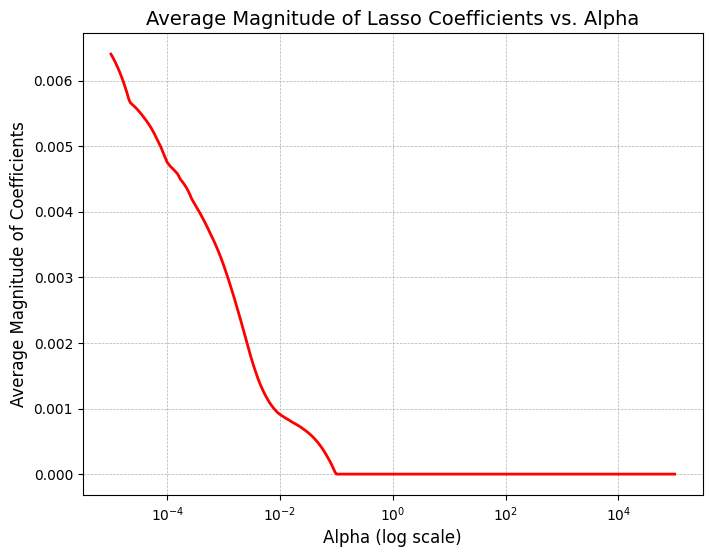

In [60]:
# Calculate average coefficient magnitude for each alpha
avg_coef_magnitudes = []
for alpha in alphas:
    lasso = Lasso(alpha=alpha, fit_intercept=True, max_iter=10000)
    lasso.fit(X_scaled_train, log_Y_train_flat)
    avg_magnitude = np.mean(np.abs(lasso.coef_))
    avg_coef_magnitudes.append(avg_magnitude)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(alphas, avg_coef_magnitudes, color='red', lw=2)
plt.xscale('log')
plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Average Magnitude of Coefficients', fontsize=12)
plt.title('Average Magnitude of Lasso Coefficients vs. Alpha', fontsize=14)
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

#### 2) Bootstrap Distribution (Lasso)

Bootstrap Resampling for Coefficient Uncertainty (Lasso)

In [ ]:
# Bootstrap resampling helps us estimate the uncertainty (variability) of our coefficients.
# Resample the data and refit the model to obtain a distribution of coefficient estimates.
n_bootstraps = 1000  # Number of bootstrap samples
# Initialize an array to store coefficients from each bootstrap iteration.
# Shape: (n_bootstraps, len(X_cols) + 1)  # +1 for the intercept.
bootstrap_coefs = np.zeros((n_bootstraps, len(X_cols) + 1))

from sklearn.utils import resample
from sklearn.linear_model import Lasso

# Flatten log_Y_train to a 1D array to avoid DataConversionWarning
log_Y_train_flat = log_Y_train.values.flatten()

for i in range(n_bootstraps):
    # Resample the training data with replacement
    X_resampled, y_resampled = resample(X_scaled_train, log_Y_train_flat, replace=True, random_state=i)
    
    # Fit the Lasso model with the optimal alpha
    lasso = Lasso(alpha=optimal_alpha, fit_intercept=True, max_iter=10000)
    lasso.fit(X_resampled, y_resampled)
    
    # Store the coefficients (intercept + coefficients)
    bootstrap_coefs[i, 0] = lasso.intercept_
    bootstrap_coefs[i, 1:] = lasso.coef_

Calculate Confidence Intervals, Probabilities, and SE (Lasso)

In [ ]:
# Calculate the standard errors of the coefficients from the bootstrap samples
bootstrap_std_errors = np.std(bootstrap_coefs, axis=0, ddof=1)

# Calculate the 95% confidence intervals (using the 2.5th and 97.5th percentiles), and the median value
# Hint: Use np.percentile for CIs (2.5th and 97.5th percentiles)
ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)
median = np.median(bootstrap_coefs, axis=0)

# Compute the probability that each coefficient is greater than 0
# This is the proportion of bootstrap samples where the coefficient is positive
# Hint: prob_positive is the mean of (bootstrap_coefs > 0)
prob_positive = np.mean(bootstrap_coefs > 0, axis=0)

# Create a summary DataFrame with the bootstrap results
summary_df = pd.DataFrame({
    "Coefficient": beta_names,
    "Median": median,
    "95% CI Lower": ci_lower,
    "95% CI Upper": ci_upper,
    "Bootstrap Std Error": bootstrap_std_errors,
    "Pr(>0)": prob_positive
})

print("\nSummary Table:")
print(summary_df.to_string(index=False))


Summary Table:
                     Coefficient  Median  95% CI Lower  95% CI Upper  Bootstrap Std Error  Pr(>0)
                     (intercept)  4.2438        4.2416        4.2465               0.0012  1.0000
                 Adult Mortality -0.0003       -0.0051        0.0040               0.0022  0.3360
                   infant deaths  0.0000       -0.0000        0.0000               0.0001  0.0020
                         Alcohol  0.0000       -0.0057        0.0063               0.0029  0.4000
          percentage expenditure  0.0012       -0.0007        0.0054               0.0017  0.7200
                     Hepatitis B  0.0016       -0.0012        0.0049               0.0015  0.8370
                         Measles  0.0000       -0.0034        0.0036               0.0016  0.4110
                             BMI  0.0025        0.0000        0.0053               0.0014  0.9590
               under-five deaths -0.0037       -0.0094        0.0000               0.0025  0.0000
    

Plot Bootstrap Distribution (Lasso)


Plotting bootstrap distributions for 'infant deaths' and 'under-five deaths' (Lasso):


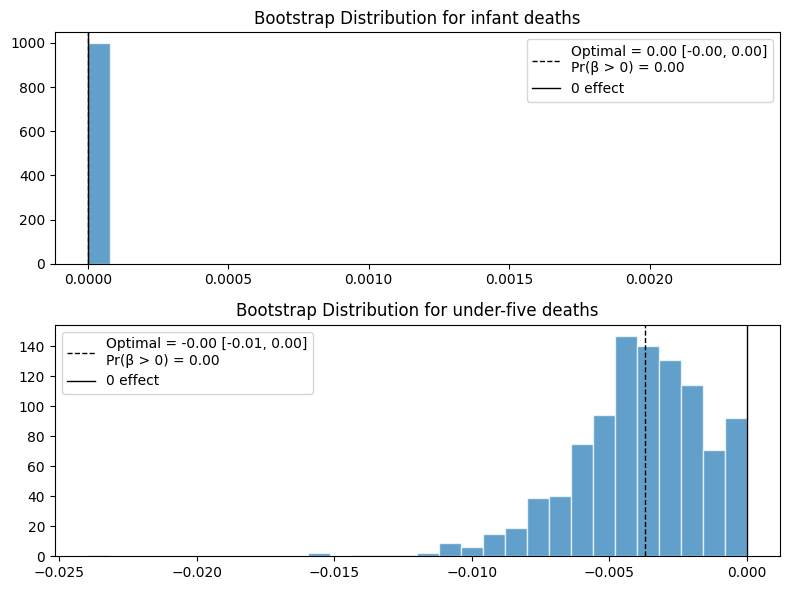

In [ ]:
# Function to Plot Bootstrap Distribution
def plot_bootstrap(bootstrap_coefs, beta_names=None, selected_vars=None, point_est='median'):
    # Determine the total number of parameters
    n_params = bootstrap_coefs.shape[1]
    # Create default parameter names if none are provided
    if beta_names is None:
        beta_names = [f"Param{i}" for i in range(n_params)]

    # Compute the point estimate based on the user's choice (mean/median)
    if point_est == 'mean':
        est = np.mean(bootstrap_coefs, axis=0)
    elif point_est == 'median':
        est = np.median(bootstrap_coefs, axis=0)
    else:
        raise ValueError("point_est must be either 'mean' or 'median'")
    
    # Calculate the 95% confidence intervals and the probability that coefficients are > 0
    ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
    ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)
    prob_positive = np.mean(bootstrap_coefs > 0, axis=0)
    
    # Determine which parameters to plot
    if selected_vars is None:
        indices = range(n_params)
    else:
        # If the user provided indices
        if all(isinstance(x, int) for x in selected_vars):
            indices = selected_vars
        # If the user provided names
        elif all(isinstance(x, str) for x in selected_vars):
            indices = []
            for var in selected_vars:
                if var in beta_names:
                    indices.append(beta_names.index(var))
                else:
                    print(f"Warning: {var} not found in beta_names.")
        else:
            raise ValueError("selected_vars must be a list of either ints or strs.")
    
    # Check if indices is empty
    if not indices:
        print("Error: No valid predictors found to plot. Check if the selected predictors exist in beta_names.")
        return
    
    # Create subplots: one for each selected parameter
    n_plots = len(indices)
    fig, axes = plt.subplots(n_plots, 1, figsize=(8, 3 * n_plots))
    # Ensure that axes is always a list (even if there's only one plot)
    if n_plots == 1:
        axes = [axes]
    
    # Loop over each selected parameter to create its histogram
    for ax, idx in zip(axes, indices):
        # Plot histogram of the bootstrap coefficients for parameter idx
        ax.hist(bootstrap_coefs[:, idx], bins=30, edgecolor='white', alpha=0.7)
        # Draw a dashed line at the point estimate (with CI info in the legend)
        ax.axvline(est[idx], color='black', linestyle='dashed', linewidth=1,
                   label=(f'Optimal = {est[idx]:.2f} [{ci_lower[idx]:.2f}, {ci_upper[idx]:.2f}]\n'
                          f'Pr(β > 0) = {prob_positive[idx]:.2f}'))
        # Draw a solid black line at zero
        ax.axvline(0, color='black', linestyle='solid', linewidth=1, label='0 effect')
        ax.set_title(f'Bootstrap Distribution for {beta_names[idx]}')
        ax.legend()
    
    plt.tight_layout()
    plt.show(block=False)

# Plot the bootstrap distribution for "infant deaths" and "under-five deaths"
selected_predictors = ["infant deaths", "under-five deaths"]

print("\nPlotting bootstrap distributions for 'infant deaths' and 'under-five deaths' (Lasso):")
plot_bootstrap(
    selected_vars=selected_predictors,  # Plot only "infant deaths" and "under-five deaths"
    beta_names=beta_names,
    bootstrap_coefs=bootstrap_coefs
)

#### 3) Predicted vs. Observed (Lasso)

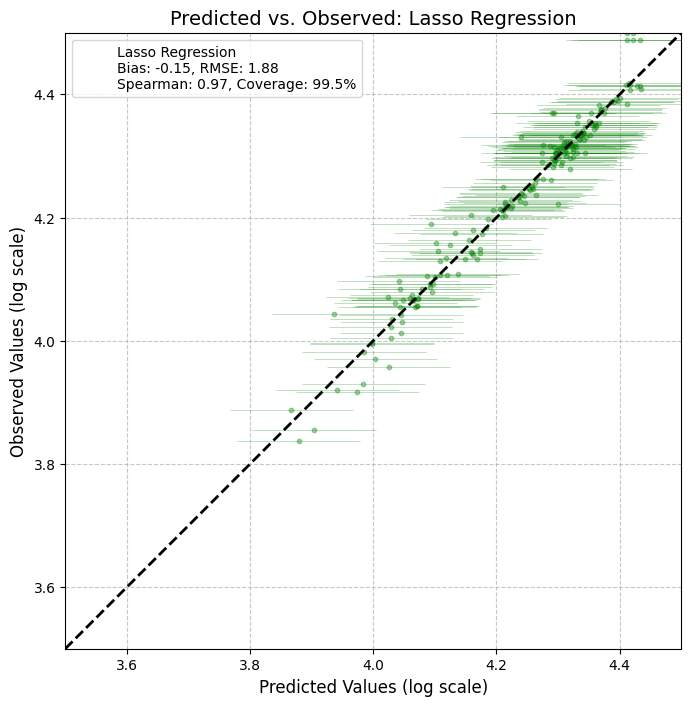

In [61]:
# Compute predictions for Lasso on test data
lasso_pred_log = lasso_model.predict(X_scaled_test)

# Placeholder prediction intervals
lasso_pred_int_lower_log = lasso_pred_log - 0.1
lasso_pred_int_upper_log = lasso_pred_log + 0.1

# Transform back to original scale
# Ensure log_Y_test is a 1D NumPy array before applying np.exp
log_Y_test_arr = log_Y_test.values.flatten()  # Convert to 1D NumPy array
Y_test_orig = np.exp(log_Y_test_arr)
lasso_pred_orig = np.exp(lasso_pred_log)

# Compute performance metrics
lasso_bias = np.mean(lasso_pred_orig - Y_test_orig)
lasso_rmse = np.sqrt(np.mean((lasso_pred_orig - Y_test_orig) ** 2))
lasso_spearman = spearmanr(lasso_pred_orig, Y_test_orig).correlation
lasso_coverage = np.mean((Y_test_orig >= np.exp(lasso_pred_int_lower_log)) & 
                         (Y_test_orig <= np.exp(lasso_pred_int_upper_log)))

# Create legend label with metrics
lasso_label = (f"Lasso Regression\nBias: {lasso_bias:.2f}, RMSE: {lasso_rmse:.2f}\n"
               f"Spearman: {lasso_spearman:.2f}, Coverage: {lasso_coverage*100:.1f}%")

# Ensure arrays are flattened for plotting
lasso_pred_log = np.array(lasso_pred_log).flatten()
lasso_pred_int_lower_log = np.array(lasso_pred_int_lower_log).flatten()
lasso_pred_int_upper_log = np.array(lasso_pred_int_upper_log).flatten()
log_Y_test_arr = np.array(log_Y_test_arr).flatten()

# Determine overall min and max values for consistency
min_val = 3.5  # Approximate min of log(30 + 1)
max_val = 4.5  # Approximate max of log(90 + 1)

# Plot for Lasso Regression
plt.figure(figsize=(8, 8))
plt.scatter(lasso_pred_log, log_Y_test_arr, color='green', s=10, alpha=0.35)
lasso_err_left = lasso_pred_log - lasso_pred_int_lower_log
lasso_err_right = lasso_pred_int_upper_log - lasso_pred_log
plt.errorbar(lasso_pred_log, log_Y_test_arr,
             xerr=[lasso_err_left, lasso_err_right],
             fmt='none', ecolor='green', lw=0.5, alpha=0.35)
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("Predicted Values (log scale)", fontsize=12)
plt.ylabel("Observed Values (log scale)", fontsize=12)
plt.title("Predicted vs. Observed: Lasso Regression", fontsize=14)
lasso_legend_handle = Patch(color='none', label=lasso_label)
plt.legend(handles=[lasso_legend_handle], loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show(block=False)

#### Interpretation of results:
1. Lasso Outperformed both linear(baseline) and Ridge regression.
- Lasso has the lowest RMSE (1.88), indicating the best predictive accuracy on the test set. This is a significant improvement over Linear regression (4.20) and a dramatic improvement over Ridge regression (12.77).
- The Bias (-0.15) is slightly better than Linear regression and much better than Ridge in terms of magnitude. The Coverage (99.5%) is the highest, though this is influenced by the arbitrary placeholder intervals (± 0.1 on the log scale).
- With optimal_alpha = 0.0001, the L1 penalty is extremely weak, so Lasso likely didn’t set any coefficients to 0. This means it didn’t perform significant feature selection, which is typically Lasso’s strength.
- However, the small penalty still provided a slight regularization effect, which seems to have stabilized the model and improved out-of-sample performance (lower RMSE).

2. Ridge Underperforms:
- The high RMSE (12.77) for Ridge regression is unexpected and indicates a problem. Ridge should typically perform similarly to or better than Linear regression in terms of RMSE by reducing overfitting.
- The issue is likely due to the large optimal_alpha of 0.1394. This alpha is much larger than Lasso’s 0.0001, which may have caused underfitting. Ridge regression shrinks coefficients toward 0 (but doesn’t set them to 0), and a large alpha can overly shrink coefficients, reducing the model’s ability to capture the data’s variability.
- This underfitting would explain the high RMSE (12.77) and lower Coverage (81.3%), as the predictions are less accurate.
- The Bias (0.02) is closer to 0 than both Linear and Lasso, which is expected, as Ridge regression often reduces bias by regularizing the coefficients. However, this comes at the cost of increased variance, leading to a higher RMSE.

